# Random Forest 

IL Random Forest non accetta valori stringhe o categorie, quindi vanno trasformati tutti i valori prima di poter applicare il modello.

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================================
# 1. CARICAMENTO DATI 
# =========================================================================
X_wo_test = pd.read_csv("X_wo_test.csv")
X_wo_train = pd.read_csv("X_wo_train.csv")

# Usiamo .squeeze("columns") per trasformare i DataFrame y in Series pulite a 1D
y_wo_test = pd.read_csv("y_wo_test.csv").squeeze("columns")
y_wo_train = pd.read_csv("y_wo_train.csv").squeeze("columns")

# =========================================================================
# 2. TRASFORMAZIONE DEL DATASET 
# =========================================================================
# anzicché lasciare la colonna anno produciamo la colonna eta_auto sottraendo l'anno corrente all'atà di produzione dell'auto
anno_corrente = datetime.now().year

X_wo_train['eta_auto'] = (anno_corrente - X_wo_train['year']).astype(int)
X_wo_test['eta_auto'] = (anno_corrente - X_wo_test['year']).astype(int)

X_wo_train = X_wo_train.drop(columns=['year'], errors='ignore')
X_wo_test = X_wo_test.drop(columns=['year'], errors='ignore')

# Cilindri
# trasformiamo la colonna cilindri in numeri interi
mappa_cilindri = {
    '8 cylinders': 8, '6 cylinders': 6, '4 cylinders': 4, '5 cylinders': 5,
    '3 cylinders': 3, '10 cylinders': 10, '12 cylinders': 12, 'Unknown': 0, 'other': 0
}
X_wo_train['cylinders'] = X_wo_train['cylinders'].map(mappa_cilindri).fillna(0).astype(int)
X_wo_test['cylinders'] = X_wo_test['cylinders'].map(mappa_cilindri).fillna(0).astype(int)

# Stato
# eliminiamo la colonna stato dal dataset
X_wo_train = X_wo_train.drop(columns=['state'], errors='ignore')
X_wo_test = X_wo_test.drop(columns=['state'], errors='ignore')

# Dimesione
# Trasformiamo la grandezza dell'auto in un indice crescente
mappa_size = { 'Unknown': 0, 'sub-compact': 1, 'compact': 2, 'mid-size': 3, 'full-size': 4 }
X_wo_train['size'] = X_wo_train['size'].map(mappa_size).fillna(0).astype(int)
X_wo_test['size'] = X_wo_test['size'].map(mappa_size).fillna(0).astype(int)

# Usura (Condition)
# Trasformiamo l'usura dell'auto in un parametro numerico crescente che definisce quanto è buona
mappa_condition = { 'Unknown': 0, 'salvage': 1, 'fair': 2, 'good': 3, 'excellent': 4, 'like new': 5, 'new': 6 }
X_wo_train['condition'] = X_wo_train['condition'].map(mappa_condition).fillna(0).astype(int)
X_wo_test['condition'] = X_wo_test['condition'].map(mappa_condition).fillna(0).astype(int)

# Chilometri
# Convertiamo da miglia a chilometri
X_wo_train['odometer'] = (X_wo_train['odometer'] * 1.60934).fillna(0).astype(int)
X_wo_test['odometer'] = (X_wo_test['odometer'] * 1.60934).fillna(0).astype(int)

# Rimozione Colore
# Eliminiamo la colonna colonna colore per una gestione più semplice
X_wo_train = X_wo_train.drop(columns=['paint_color'], errors='ignore')
X_wo_test = X_wo_test.drop(columns=['paint_color'], errors='ignore')

# =========================================================================
# 3. CODIFICHE ONE-HOT ENCODING (GET_DUMMIES)
# =========================================================================
# Stato Legale (Title Status) con One-Hot Encoding
X_wo_train = pd.get_dummies(X_wo_train, columns=['title_status'], prefix='title', dtype=int)
X_wo_test = pd.get_dummies(X_wo_test, columns=['title_status'], prefix='title', dtype=int)
X_wo_train = X_wo_train.drop(columns=['title_status_Unknown'], errors='ignore')
X_wo_test = X_wo_test.drop(columns=['title_status_Unknown'], errors='ignore')

# Trazione (Drive) con azzeramento manuale degli Unknown
X_wo_train = pd.get_dummies(X_wo_train, columns=['drive'], prefix='drive', dtype=int)
X_wo_test = pd.get_dummies(X_wo_test, columns=['drive'], prefix='drive', dtype=int)
X_wo_train = X_wo_train.drop(columns=['drive_Unknown'], errors='ignore')
X_wo_test = X_wo_test.drop(columns=['drive_Unknown'], errors='ignore')

# Cambio (Transmission) e Carburante (Fuel)
X_wo_train = pd.get_dummies(X_wo_train, columns=['transmission', 'fuel'], prefix=['trans', 'fuel'], dtype=int)
X_wo_test = pd.get_dummies(X_wo_test, columns=['transmission', 'fuel'], prefix=['trans', 'fuel'], dtype=int)

# =========================================================================
# 4. UNICO ALLINEAMENTO STRUTTURALE FINALE DI SICUREZZA
# =========================================================================
X_wo_test = X_wo_test.reindex(columns=X_wo_train.columns, fill_value=0)

# =========================================================================
# 5. FILTRO CHIRURGICO DEGLI OUTLIERS SUL PREZZO (RISOLTO COI VETTORI)
# =========================================================================
print(f"Righe iniziali Train: {X_wo_train.shape[0]}")

# Risoluzione del bug: convertiamo esplicitamente in vettori NumPy 1D per evitare conflitti di colonne
vettore_prezzi_train = y_wo_train.to_numpy().flatten()
vettore_prezzi_test = y_wo_test.to_numpy().flatten()

limite_prezzo_train = (vettore_prezzi_train >= 500) & (vettore_prezzi_train <= 100000)
X_wo_train = X_wo_train[limite_prezzo_train]
y_wo_train = y_wo_train[limite_prezzo_train]

limite_prezzo_test = (vettore_prezzi_test >= 500) & (vettore_prezzi_test <= 100000)
X_wo_test = X_wo_test[limite_prezzo_test]
y_wo_test = y_wo_test[limite_prezzo_test]

print(f"Righe rimaste Train dopo il filtro prezzo: {X_wo_train.shape[0]}")

# =========================================================================
# 6. ISOLAMENTO NUMERICO E RUN DELLA RANDOM FOREST
# =========================================================================
X_wo_train_rf = X_wo_train.select_dtypes(include=[np.number])
X_wo_test_rf = X_wo_test.select_dtypes(include=[np.number])

print(f"Numero di feature usate: {X_wo_train_rf.shape[1]}")

modello_wo_rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
modello_wo_rf.fit(X_wo_train_rf, y_wo_train)
print("-> Addestramento completato con successo!")

# Predizione e Metriche
y_pred = modello_wo_rf.predict(X_wo_test_rf)

mae = mean_absolute_error(y_wo_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_wo_test, y_pred))
r2 = r2_score(y_wo_test, y_pred)

print("\n=========================================================================")
print("📊 NUOVE PRESTAZIONI DELLA RANDOM FOREST:")
print(f"-> Errore Medio Assoluto (MAE): {mae:.2f} $")
print(f"-> Radice dell'Errore Quadratico Medio (RMSE): {rmse:.2f} $")
print(f"-> Coefficiente di Determinazione (R²): {r2:.4f}")
print("=========================================================================")

Righe iniziali Train: 274755
Righe rimaste Train dopo il filtro prezzo: 274755
Numero di feature usate: 22
-> Addestramento completato con successo!

📊 NUOVE PRESTAZIONI DELLA RANDOM FOREST:
-> Errore Medio Assoluto (MAE): 2387.67 $
-> Radice dell'Errore Quadratico Medio (RMSE): 4798.23 $
-> Coefficiente di Determinazione (R²): 0.8645


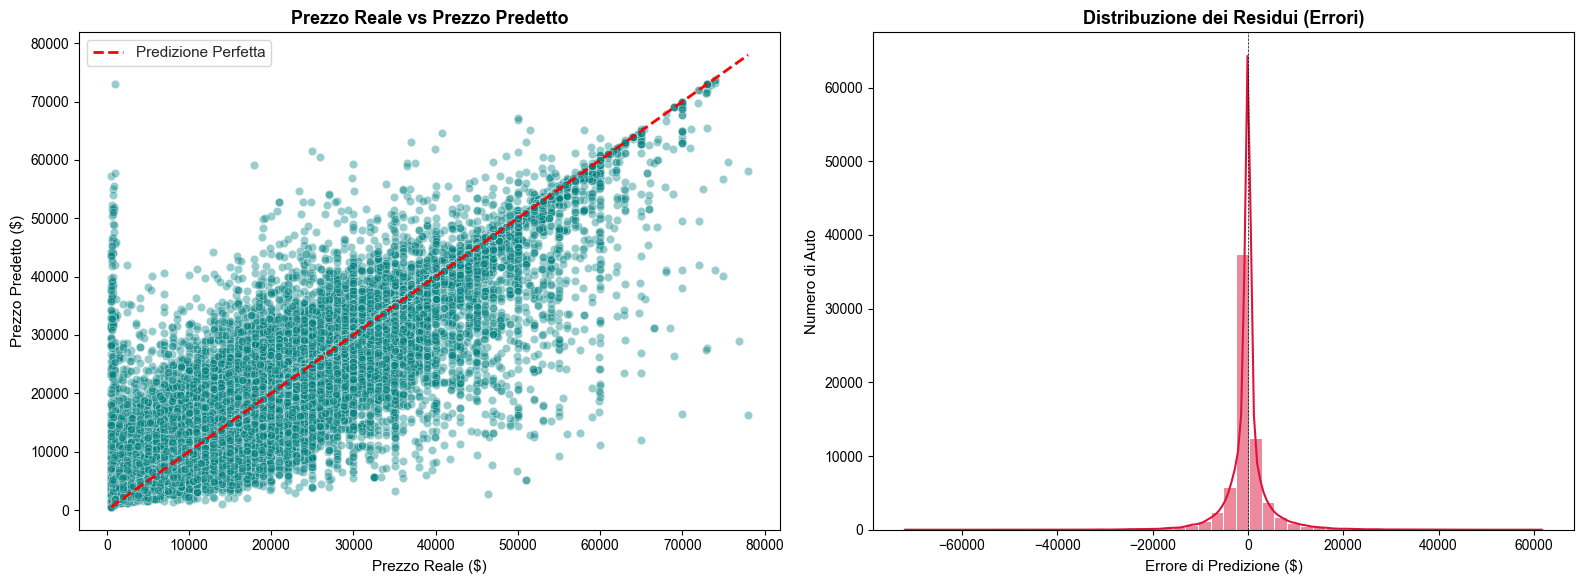


🔍 I 5 ERRORI PIÙ GRAVI DEL MODELLO (SOTTOSTIME O SOVRASTIME EPICHE):
       Reale      Predetto  Errore_Assoluto
50441   1030  72995.000000     71965.000000
14107  78000  16280.189000     61719.811000
64081   1008  57784.186000     56776.186000
51806    572  57325.590000     56753.590000
44000    833  55517.321767     54684.321767


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# DIAGNOSTICA DEGLI ERRORI
# 1. Calcoliamo i residui sul set di test
residui = y_wo_test - y_pred

# Creiamo una figura con due grafici affiancati (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------------------
# GRAFICO A: Prezzo Reale vs Prezzo Predetto
# -------------------------------------------------------------------------
sns.scatterplot(ax=axes[0], x=y_wo_test, y=y_pred, alpha=0.4, color='teal')

# Disegniamo la linea di "predizione perfetta" a 45 gradi
limiti = [min(y_wo_test.min(), y_pred.min()), max(y_wo_test.max(), y_pred.max())]
axes[0].plot(limiti, limiti, color='red', linestyle='--', linewidth=2, label='Predizione Perfetta')

axes[0].set_title("Prezzo Reale vs Prezzo Predetto", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Prezzo Reale ($)", fontsize=11)
axes[0].set_ylabel("Prezzo Predetto ($)", fontsize=11)
axes[0].legend()

# -------------------------------------------------------------------------
# GRAFICO B: Distribuzione degli Errori (Residui)
# -------------------------------------------------------------------------
sns.histplot(ax=axes[1], x=residui, kde=True, color='crimson', bins=50)

# Disegniamo la linea sullo zero (errore nullo)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.5)

axes[1].set_title("Distribuzione dei Residui (Errori)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Errore di Predizione ($)", fontsize=11)
axes[1].set_ylabel("Numero di Auto", fontsize=11)

plt.tight_layout()
plt.show()


# =========================================================================
# ANALISI EXTRA: DOVE SBAGLIA DI PIÙ?
# =========================================================================
# Creiamo un piccolo DataFrame per isolare i casi peggiori
analisi_errori = pd.DataFrame({
    'Reale': y_wo_test,
    'Predetto': y_pred,
    'Errore_Assoluto': np.abs(residui)
}).sort_values(by='Errore_Assoluto', ascending=False)

print("\n=========================================================================")
print("🔍 I 5 ERRORI PIÙ GRAVI DEL MODELLO (SOTTOSTIME O SOVRASTIME EPICHE):")
print("=========================================================================")
print(analisi_errori.head())
print("=========================================================================")

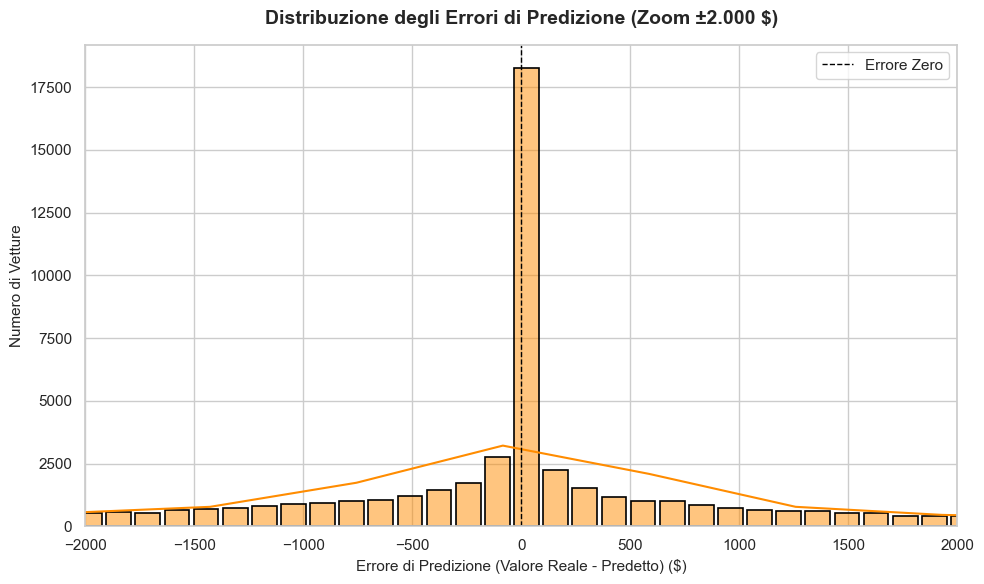

📊 ANALISI DI PRECISIONE NELLO ZOOM:
-> Il 66.9% delle auto nel test set viene predetto con un errore inferiore a 2000 $.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ISTOGRAMMA DEI RESIDUI ZOOMATO (TRA -2000$ E +2000$)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.histplot(
    residui, 
    kde=True, 
    color='darkorange', 
    bins=1000,           
    shrink=0.85,
    edgecolor='black',  
    linewidth=1.2       
)

# Applichiamo il limite richiesto sull'asse delle X
plt.xlim(-2000, 2000)

# 4. Linea nera di riferimento sullo ZERO (il punto di predizione perfetta)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Errore Zero')

# Personalizzazione estetica
plt.title("Distribuzione degli Errori di Predizione (Zoom ±2.000 $)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Errore di Predizione (Valore Reale - Predetto) ($)", fontsize=11)
plt.ylabel("Numero di Vetture", fontsize=11)
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================================
# CALCOLO DELLA PERCENTUALE DI ERRORI IN QUESTA FASCIA
# =========================================================================
# Giusto per darti un dato numerico da spendere nella relazione/analisi:
auto_nella_fascia = ((residui >= -2000) & (residui <= 2000)).sum()
percentuale = (auto_nella_fascia / len(residui)) * 100

print(f"📊 ANALISI DI PRECISIONE NELLO ZOOM:")
print(f"-> Il {percentuale:.1f}% delle auto nel test set viene predetto con un errore inferiore a 2000 $.")
print("=========================================================================")

MARCHE CON L'ERRORE MEDIO (MAE) PIÙ ALTO ED INCIDENZA SUL TOTALE:
          marca auto_sbagliate auto_totali percentuale_errate  mae_marca errore_percentuale_medio
        porsche            177         230              77.0% 10775.83 $                    35.0%
          rover            228         310              73.5%  6895.17 $                    25.3%
          tesla             47         130              36.2%  6669.93 $                    17.4%
         datsun              9          12              75.0%  6051.86 $                    76.2%
harley-davidson             21          22              95.5%  4756.09 $                    38.1%
         jaguar            151         365              41.4%  4504.79 $                    22.1%
            ram          1,864       2,950              63.2%  4265.22 $                    15.0%
            gmc          1,881       2,858              65.8%  4166.40 $                    18.7%
  mercedes-benz          1,386       1,878          

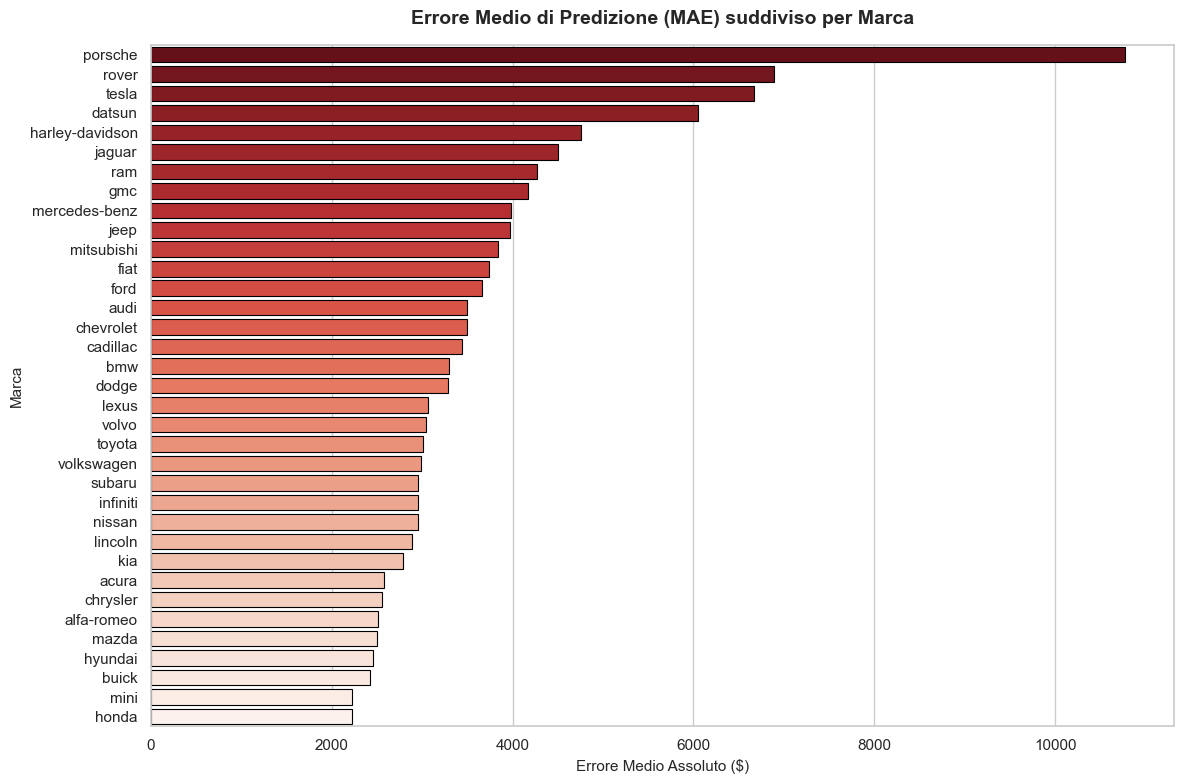

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Recuperiamo la colonna originale delle marche da X_wo_test prima del One-Hot Encoding.
colonne_make = [col for col in X_wo_test.columns if col.startswith('make_')]

if colonne_make:
    # Trucco inverso: idxmax trova la colonna con il valore 1, poi togliamo il prefisso 'make_'
    marche_ricostruite = X_wo_test[colonne_make].idxmax(axis=1).str.replace('make_', '')
else:
    # Se per caso hai ancora la colonna originale non codificata nel dataset
    marche_ricostruite = X_wo_test['manufacturer']

# Creiamo il DataFrame contenente i reali, i predetti e gli errori
df_errori = pd.DataFrame({
    'marca': marche_ricostruite,
    'prezzo_reale': y_wo_test,
    'prezzo_predetto': y_pred,
    'errore_assoluto': np.abs(y_wo_test - y_pred)
})

# =========================================================================
# 2. AGGREGAZIONE E CALCOLO DELLE PERCENTUALI DI ERRORE PER MARCA
# =========================================================================
# 2a. Calcoliamo i volumi totali di auto nel test set per ogni marca
volumi_totali = df_errori.groupby('marca').size().to_frame('auto_totali')

# 2b. Applichiamo il filtro sulle auto con errore > 100$
df_errori_oltre_100 = df_errori[df_errori['errore_assoluto'] > 100]

# 2c. Aggreghiamo i dati delle sole auto deviate
analisi_marche = (
    df_errori_oltre_100.groupby('marca')
    .agg(
        auto_sbagliate=('errore_assoluto', 'count'),
        mae_marca=('errore_assoluto', 'mean'),
        prezzo_reale_medio=('prezzo_reale', 'mean')
    )
)

# 2d. Uniamo i volumi totali per calcolare la percentuale di errore sul totale
analisi_marche = volumi_totali.join(analisi_marche, how='left').fillna({'auto_sbagliate': 0, 'mae_marca': 0}).reset_index()

# Calcoliamo le percentuali richieste
analisi_marche['percentuale_errate'] = (analisi_marche['auto_sbagliate'] / analisi_marche['auto_totali']) * 100
analisi_marche['errore_percentuale_medio'] = (analisi_marche['mae_marca'] / analisi_marche['prezzo_reale_medio']) * 100

# Ordiniamo la classifica in base al MAE più alto
# Escludiamo eventuali marche con MAE a 0 per non sporcare il grafico/tabella
analisi_marche = analisi_marche[analisi_marche['mae_marca'] > 0]
analisi_marche = analisi_marche.sort_values(by='mae_marca', ascending=False).reset_index(drop=True)

print("=====================================================================================================")
print("MARCHE CON L'ERRORE MEDIO (MAE) PIÙ ALTO ED INCIDENZA SUL TOTALE:")
print("=====================================================================================================")
print(analisi_marche[['marca', 'auto_sbagliate', 'auto_totali', 'percentuale_errate', 'mae_marca', 'errore_percentuale_medio']].head(35).to_string(index=False, formatters={
    'auto_totali': '{:,.0f}'.format,
    'auto_sbagliate': '{:,.0f}'.format,
    'percentuale_errate': '{:.1f}%'.format,
    'mae_marca': '{:.2f} $'.format,
    'errore_percentuale_medio': '{:.1f}%'.format
}))
print("=====================================================================================================")


# =========================================================================
# 3. GRAFICO DEL MAE PER OGNI MARCA (DOVE SBAGLIA DI PIÙ?)
# =========================================================================
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='mae_marca',
    y='marca',
    data=analisi_marche,
    palette='Reds_r',
    hue='marca',
    legend=False,
    edgecolor='black',
    linewidth=0.8
)

plt.title("Errore Medio di Predizione (MAE) suddiviso per Marca", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Errore Medio Assoluto ($)", fontsize=11)
plt.ylabel("Marca", fontsize=11)

plt.tight_layout()
plt.show()

CLASSIFICA MARCHE: ORDINATA PER INCIDENZA DELLE AUTO ERRATE (ERRORE > 10%)
          marca auto_sbagliate auto_totali percentuale_auto_errate errore_relativo_medio  mae_marca
harley-davidson             18          22                   81.8%                 75.9%  5454.79 $
         datsun              9          12                   75.0%                144.4%  6051.86 $
        porsche            140         230                   60.9%                 41.0% 13292.29 $
         nissan          1,651       3,114                   53.0%                 76.1%  4151.62 $
          honda          1,907       3,651                   52.2%                 69.2%  3114.34 $
       chrysler            528       1,027                   51.4%                 77.2%  3589.61 $
          dodge          1,081       2,179                   49.6%                 89.6%  4668.84 $
         subaru            833       1,694                   49.2%                 80.7%  4367.89 $
           fiat          

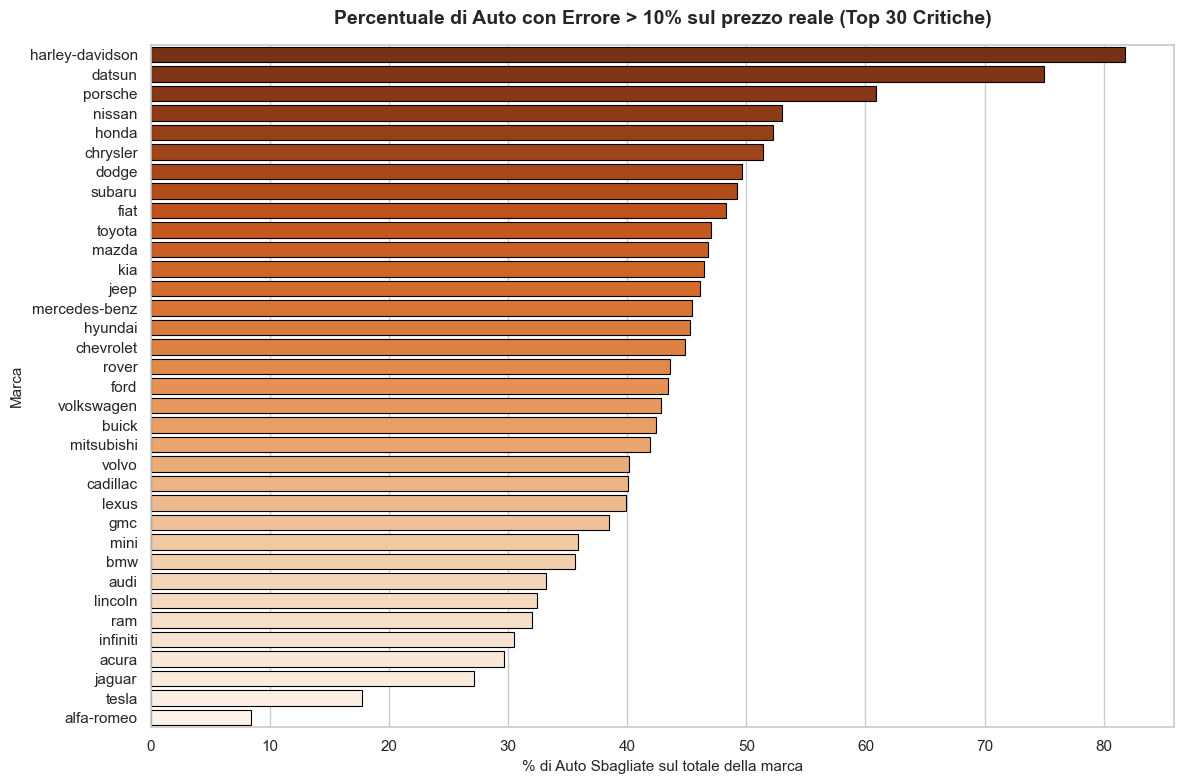

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. RECUPERO MARCHE E CALCOLO ERRORE RELATIVO
# =========================================================================
colonne_make = [col for col in X_wo_test.columns if col.startswith('make_')]

if colonne_make:
    marche_ricostruite = X_wo_test[colonne_make].idxmax(axis=1).str.replace('make_', '')
else:
    marche_ricostruite = X_wo_test['manufacturer']

# Creiamo il DataFrame principale
df_errori = pd.DataFrame({
    'marca': marche_ricostruite,
    'prezzo_reale': y_wo_test,
    'prezzo_predetto': y_pred,
    'errore_assoluto': np.abs(y_wo_test - y_pred)
})

# Calcoliamo l'errore relativo percentuale rispetto al prezzo REALE dell'auto
# Esempio: se errore_assoluto è 1500 e il prezzo reale è 10000 -> 15%
df_errori['errore_relativo_pct'] = (df_errori['errore_assoluto'] / df_errori['prezzo_reale']) * 100

# =========================================================================
# 2. AGGREGAZIONE CON SOGLIA DEL 10%
# =========================================================================
# 2a. Volumi totali per marca
volumi_totali = df_errori.groupby('marca').size().to_frame('auto_totali')

# 2b. Filtriamo le auto "sbagliate": l'errore percentuale supera il 10%
df_sbagliate_oltre_10pct = df_errori[df_errori['errore_relativo_pct'] > 10.0]

# 2c. Aggreghiamo i dati delle auto che superano la tolleranza
analisi_marche = (
    df_sbagliate_oltre_10pct.groupby('marca')
    .agg(
        auto_sbagliate=('errore_relativo_pct', 'count'),
        mae_marca=('errore_assoluto', 'mean'),  # Errore medio in $ per quel brand
        errore_relativo_medio=('errore_relativo_pct', 'mean') # Errore percentuale medio
    )
)

# 2d. Uniamo i totali per calcolare l'indice di errore della marca
analisi_marche = volumi_totali.join(analisi_marche, how='left').fillna({'auto_sbagliate': 0, 'mae_marca': 0, 'errore_relativo_medio': 0}).reset_index()

# Percentuale di auto che hanno superato la barriera del 10% sul totale di quella marca
analisi_marche['percentuale_auto_errate'] = (analisi_marche['auto_sbagliate'] / analisi_marche['auto_totali']) * 100

# Ordiniamo la classifica per mettere in cima le marche con la PERCENTUALE PIÙ ALTA DI AUTO SBAGLIATE
analisi_marche = analisi_marche.sort_values(by='percentuale_auto_errate', ascending=False).reset_index(drop=True)

# =========================================================================
# 3. STAMPA DELLA NUOVA TABELLA METRICA
# =========================================================================
print("=====================================================================================================")
print("CLASSIFICA MARCHE: ORDINATA PER INCIDENZA DELLE AUTO ERRATE (ERRORE > 10%)")
print("=====================================================================================================")
print(analisi_marche[['marca', 'auto_sbagliate', 'auto_totali', 'percentuale_auto_errate', 'errore_relativo_medio', 'mae_marca']].head(35).to_string(index=False, formatters={
    'auto_totali': '{:,.0f}'.format,
    'auto_sbagliate': '{:,.0f}'.format,
    'percentuale_auto_errate': '{:.1f}%'.format,
    'errore_relativo_medio': '{:.1f}%'.format,
    'mae_marca': '{:.2f} $'.format
}))
print("=====================================================================================================")

# =========================================================================
# 4. NUOVO GRAFICO SULL'INCIDENZA DELLO SBAGLIO
# =========================================================================
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Visualizziamo la percentuale di auto fallite per capire subito quali marche soffrono di più lo split
sns.barplot(
    x='percentuale_auto_errate',
    y='marca',
    data=analisi_marche.head(35), # Mostriamo le prime 30 critiche per non affollare l'asse Y
    palette='Oranges_r',
    hue='marca',
    legend=False,
    edgecolor='black',
    linewidth=0.8
)

plt.title("Percentuale di Auto con Errore > 10% sul prezzo reale (Top 30 Critiche)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("% di Auto Sbagliate sul totale della marca", fontsize=11)
plt.ylabel("Marca", fontsize=11)

plt.tight_layout()
plt.show()